# Neural Networks in PyTorch - Optimizers & Schedulers

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

# Set random seed for reproducibility
torch.manual_seed(302)
np.random.seed(302)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000])

print(train_dataset); print(test_dataset)

# Creating data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

100.0%
100.0%
100.0%
100.0%

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [2]:
class NeuralNet(nn.Module):
    def __init__(self):
      super(NeuralNet, self).__init__()
      self.fc1 = nn.Linear(in_features=28*28, out_features=128)
      self.fc2 = nn.Linear(in_features=128, out_features=128)
      self.fc3 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
      # Flatten the data (B, 1, 28, 28) => (B, 784), where B is the batch size
      x = torch.flatten(x, start_dim=1)

      # Pass data through 1st fully connected layer
      x = self.fc1(x)
      # Apply ReLU non-linearity
      x = F.relu(x)

      # Pass data through 2nd fully connected layer
      x = self.fc2(x)
      # Apply ReLU non-linearity
      x = F.relu(x)

      # Pass data through 3rd fully connected layer
      x = self.fc3(x)

      # The output values in x are called *logits*
      return x

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = NeuralNet().to(device)
print(model)

# Parameters of the model
for p in model.parameters():
    print(p.shape)

NeuralNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
torch.Size([128, 784])
torch.Size([128])
torch.Size([128, 128])
torch.Size([128])
torch.Size([10, 128])
torch.Size([10])


In [4]:
def train_model(model, optimizer, train_loader, val_loader, device, num_epochs=5):
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []
    for epoch in range(num_epochs):
        print('-'*20, f'Epoch {epoch}', '-'*20)

        # Train one epoch
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = loss_fn(outputs, target)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        print(f'Train Epoch {epoch} | Average Training Loss {np.mean(train_losses[-len(train_loader):])}')

        # Evaluate on validation set at the end of the epoch
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                val_loss += loss_fn(outputs, target).item()
                probs = F.softmax(outputs, dim=1)
                pred = torch.argmax(probs, dim=1)  # get the index of the max probability as the predicted output
                correct += (pred == target).sum().item()

        val_loss = val_loss / len(val_loader)
        avg_correct = correct / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(avg_correct)
        print(f'Validation set: Average loss: {val_loss:.4f}, Accuracy: {correct}/{len(val_loader.dataset)} ({100. * avg_correct:.0f}%)\n')

    return train_losses, val_losses, val_accuracies

## Comparison of different optimizers

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

epochs = 5

print(f'Optimizer: SGD')
model = NeuralNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
train_losses, val_losses, val_accuracies = train_model(model, optimizer, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)

print(f'Optimizer: SGD with Momentum')
model = NeuralNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
train_losses, val_losses, val_accuracies = train_model(model, optimizer, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)

print(f'Optimizer: RMSProp')
model = NeuralNet().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
train_losses, val_losses, val_accuracies = train_model(model, optimizer, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)

print(f'Optimizer: Adam')
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses, val_losses, val_accuracies = train_model(model, optimizer, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)

Optimizer: SGD
-------------------- Epoch 0 --------------------
Train Epoch 0 | Average Training Loss 1.1241610436259633
Validation set: Average loss: 0.4917, Accuracy: 8645/10000 (86%)

-------------------- Epoch 1 --------------------
Train Epoch 1 | Average Training Loss 0.40861109886175534
Validation set: Average loss: 0.4059, Accuracy: 8845/10000 (88%)

-------------------- Epoch 2 --------------------
Train Epoch 2 | Average Training Loss 0.3388437771755259
Validation set: Average loss: 0.3354, Accuracy: 9000/10000 (90%)

-------------------- Epoch 3 --------------------
Train Epoch 3 | Average Training Loss 0.30325426934930066
Validation set: Average loss: 0.2961, Accuracy: 9157/10000 (92%)

-------------------- Epoch 4 --------------------
Train Epoch 4 | Average Training Loss 0.27959978380395323
Validation set: Average loss: 0.2686, Accuracy: 9224/10000 (92%)

Final validation set accuracy:  0.9224
--------------------------------------------------
Optimizer: SGD with Momentu

# Comparison of different learning rate schedules

Schedulers adjust the learning rate based on the number of epochs or other factors.

In [6]:
def train_model_with_scheduler(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs=5):
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []
    for epoch in range(num_epochs):
        print('-'*20, f'Epoch {epoch}', '-'*20)

        # Train one epoch
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = loss_fn(outputs, target)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        scheduler.step() # update learning rate based on the schedule !!!

        print(f'Train Epoch {epoch} | Average Training Loss {np.mean(train_losses[-len(train_loader):])} | Learning rate: {np.round(scheduler.get_last_lr()[0], 5)}')

        # Evaluate on validation set at the end of the epoch
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                val_loss += loss_fn(outputs, target).item()
                probs = F.softmax(outputs, dim=1)
                pred = torch.argmax(probs, dim=1)  # get the index of the max log-probability
                correct += (pred == target).sum().item()

        val_loss = val_loss / len(val_loader)
        avg_correct = correct / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(avg_correct)
        print(f'Validation set: Average loss: {val_loss:.4f}, Accuracy: {correct}/{len(val_loader.dataset)} ({100. * avg_correct:.0f}%)\n')

    return train_losses, val_losses, val_accuracies

In [7]:
def plot_scheduler_lr(name, scheduler, num_epochs=50):
    lrs = []
    for _ in range(num_epochs):
        lrs.append(scheduler.get_last_lr())
        scheduler.step()

    plt.title(name)
    plt.plot(lrs)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.show()

Scheduler: StepLR


/opt/miniconda3/envs/ml1/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


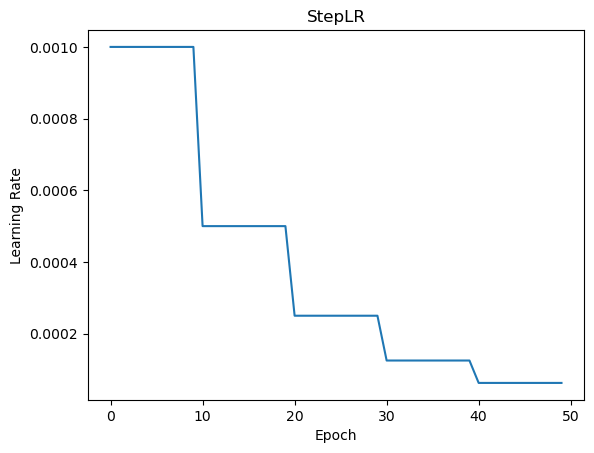

-------------------- Epoch 0 --------------------
Train Epoch 0 | Average Training Loss 1.3695786436805335 | Learning rate: 3e-05
Validation set: Average loss: 0.6890, Accuracy: 8430/10000 (84%)

-------------------- Epoch 1 --------------------
Train Epoch 1 | Average Training Loss 0.5445453270202707 | Learning rate: 3e-05
Validation set: Average loss: 0.4424, Accuracy: 8816/10000 (88%)

-------------------- Epoch 2 --------------------
Train Epoch 2 | Average Training Loss 0.41111115629182143 | Learning rate: 3e-05
Validation set: Average loss: 0.3739, Accuracy: 8952/10000 (90%)

-------------------- Epoch 3 --------------------
Train Epoch 3 | Average Training Loss 0.36112518557121076 | Learning rate: 3e-05
Validation set: Average loss: 0.3408, Accuracy: 9022/10000 (90%)

-------------------- Epoch 4 --------------------
Train Epoch 4 | Average Training Loss 0.33355082006520015 | Learning rate: 3e-05
Validation set: Average loss: 0.3206, Accuracy: 9092/10000 (91%)

-----------------

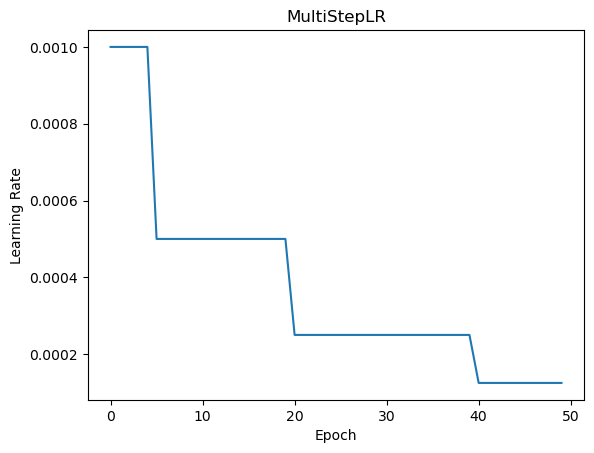

-------------------- Epoch 0 --------------------
Train Epoch 0 | Average Training Loss 0.71824088387782 | Learning rate: 0.00012
Validation set: Average loss: 0.3601, Accuracy: 8971/10000 (90%)

-------------------- Epoch 1 --------------------
Train Epoch 1 | Average Training Loss 0.32263644573176303 | Learning rate: 0.00012
Validation set: Average loss: 0.2879, Accuracy: 9175/10000 (92%)

-------------------- Epoch 2 --------------------
Train Epoch 2 | Average Training Loss 0.2734343082836979 | Learning rate: 0.00012
Validation set: Average loss: 0.2504, Accuracy: 9263/10000 (93%)

-------------------- Epoch 3 --------------------
Train Epoch 3 | Average Training Loss 0.23997092519498542 | Learning rate: 0.00012
Validation set: Average loss: 0.2291, Accuracy: 9336/10000 (93%)

-------------------- Epoch 4 --------------------
Train Epoch 4 | Average Training Loss 0.21021720293499624 | Learning rate: 0.00012
Validation set: Average loss: 0.2014, Accuracy: 9426/10000 (94%)

---------

In [ ]:
from torch.optim.lr_scheduler import StepLR, MultiStepLR, CosineAnnealingLR, CosineAnnealingWarmRestarts

device = 'cuda' if torch.cuda.is_available() else 'cpu'

epochs = 50

print(f'Scheduler: StepLR')
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
plot_scheduler_lr('StepLR', scheduler)
train_losses, val_losses, val_accuracies = train_model_with_scheduler(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)

print(f'Scheduler: MultiStepLR')
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = MultiStepLR(optimizer, milestones=[5, 20, 40], gamma=0.5)
plot_scheduler_lr('MultiStepLR', scheduler)
train_losses, val_losses, val_accuracies = train_model_with_scheduler(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)

print(f'Scheduler: CosineAnnealingLR')
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=50)
plot_scheduler_lr('CosineAnnealingLR', scheduler)
train_losses, val_losses, val_accuracies = train_model_with_scheduler(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs=epochs)
print('Final validation set accuracy: ', val_accuracies[-1])
print('-'*50)
